<a href="https://colab.research.google.com/github/WendelLeander/PhishEvade/blob/main/preprocessing_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Preprocessing Pipeline
### Obfuscation-Aware Feature Engineering for Phishing URL Detection

This notebook documents and implements the **five-step data preprocessing pipeline**
described in Section 3.7.1 of the study proposal. It is applied to the aggregated,
balanced-source dataset (`Final Dataset.csv`, 10,000 URLs: 5,000 benign / 5,000
malicious) **before** any lexical or obfuscation-aware feature is extracted.

Raw datasets sourced from public repositories (PhishTank, PhishStats, Tranco,
Majestic Million, and the Wayback-collected benign-obfuscated set) frequently
contain duplicate entries, malformed strings, missing values, and inconsistent
text formatting. Left unaddressed, these issues distort feature computation and
introduce bias into the trained models.

**Pipeline overview**

| # | Technique | Purpose |
|---|---|---|
| 1 | Duplicate Removal | Prevent any single sample from being overrepresented / prevent data leakage |
| 2 | Null & Corrupted Entry Removal | Preserve structural integrity of every row |
| 3 | Text Standardization | Remove casing/protocol noise that is not meaningful structural variation |
| 4 | Tokenization (Component Parsing) | Decompose each URL into protocol, domain, subdomain, path, query |
| 5 | Class Balancing (50:50) | Prevent classifier bias toward the numerically dominant class |

Each section below explains the rationale, shows the code, and reports the
row count **before** and **after** the step so the effect of each technique is
auditable.


## 0. Setup and Dataset Load

The dataset is read from `Final Dataset.csv`, expected to sit in the same
folder as this notebook (or adjust `DATA_PATH` below). The file is the output
of the benign/malicious aggregation + merge scripts and already carries a
numeric `label` column (`0` = benign, `1` = malicious).


In [3]:
import re
import numpy as np
import pandas as pd
from urllib.parse import urlsplit

import matplotlib.pyplot as plt

try:
    import tldextract
    _EXTRACT = tldextract.TLDExtract(suffix_list_urls=(), cache_dir=None)
    _HAS_TLDEXTRACT = True
except ImportError:
    _HAS_TLDEXTRACT = False
    print("tldextract not installed (pip install tldextract) — "
          "subdomain/domain split in Step 4 will fall back to a simpler heuristic.")

pd.set_option("display.max_colwidth", 80)
RANDOM_SEED = 42

DATA_PATH = "Final Dataset.csv"
df = pd.read_csv(DATA_PATH)

# audit trail: row count after each pipeline step
audit = [("0. Raw input", len(df))]

print(f"Loaded {len(df):,} rows from '{DATA_PATH}'")
print(f"Columns: {list(df.columns)}")
df.head()

tldextract not installed (pip install tldextract) — subdomain/domain split in Step 4 will fall back to a simpler heuristic.


FileNotFoundError: [Errno 2] No such file or directory: 'Final Dataset.csv'

In [ ]:
df.info()
print()
print("Label value counts:")
print(df["label"].value_counts(dropna=False))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   url     10000 non-null  object
 1   label   10000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 156.4+ KB

Label value counts:
label
1    5000
0    5000
Name: count, dtype: int64


## 1. Duplicate Removal

Duplicate URL entries are identified and removed **first**, before any other
cleaning step. Two sources could introduce duplicates here: the three benign
sources (Tranco, Majestic, the Wayback-collected obfuscated set) can surface
the same URL twice, and the same is true across the malicious sources
(PhishStats, PhishTank). Removing duplicates up front stops any single sample
from being overrepresented during training, and prevents the same URL from
appearing in both the training and test split later (data leakage).

De-duplication is performed on the `url` column specifically (rather than the
full row), since that is the only column that can repeat across sources.


In [ ]:
n_before = len(df)
dup_mask = df.duplicated(subset=["url"], keep="first")
n_duplicates = int(dup_mask.sum())

print(f"Duplicate URLs found: {n_duplicates:,} of {n_before:,} rows")
if n_duplicates:
    display(df.loc[dup_mask, "url"].head(5).to_frame())

df = df.loc[~dup_mask].reset_index(drop=True)
audit.append(("1. After duplicate removal", len(df)))
print(f"Rows remaining: {len(df):,}")

Duplicate URLs found: 0 of 10,000 rows
Rows remaining: 10,000


## 2. Null & Corrupted Entry Removal

Null, corrupted, or incomplete entries — truncated strings or rows missing a
class label — are removed next, to preserve the structural integrity of every
remaining row. This covers three cases:

1. A missing (`NaN`) `url` or `label`.
2. An empty or whitespace-only `url` string (a corrupted row that survives a
   naive `dropna()` because the cell is not technically `NaN`).
3. A `label` value outside the expected `{0, 1}` binary encoding, which would
   indicate a corrupted or mis-mapped row.


In [ ]:
n_before = len(df)

null_mask = df["url"].isna() | df["label"].isna()
blank_mask = df["url"].astype(str).str.strip().eq("")
bad_label_mask = ~df["label"].isin([0, 1])

drop_mask = null_mask | blank_mask | bad_label_mask
n_dropped = int(drop_mask.sum())

print(f"Null/empty url or label: {int(null_mask.sum()):,}")
print(f"Blank (whitespace-only) url: {int((blank_mask & ~null_mask).sum()):,}")
print(f"Invalid label value (not 0/1): {int((bad_label_mask & ~null_mask).sum()):,}")
print(f"Total rows dropped: {n_dropped:,} of {n_before:,}")

df = df.loc[~drop_mask].reset_index(drop=True)
audit.append(("2. After null/corrupted removal", len(df)))
print(f"Rows remaining: {len(df):,}")

Null/empty url or label: 0
Blank (whitespace-only) url: 0
Invalid label value (not 0/1): 0
Total rows dropped: 0 of 10,000
Rows remaining: 10,000


## 3. Text Standardization

URL strings are standardized so that casing and protocol prefixes are not
mistaken for meaningful structural variation:

1. **Lowercase** the entire string — `HTTPS://Example.COM` and
   `https://example.com` should be treated as the same structural input.
2. **Strip the leading protocol** (`http://` or `https://`) — the scheme is a
   fixed, low-information prefix that would otherwise inflate length-based
   features identically across almost every row.

The original string is preserved in `url_raw` for traceability; `url` is
overwritten with the standardized form and used by every step from here on.

> **Note on `www.`:** the original raw URLs include both `www.`-prefixed and
> bare-domain hosts (by design — the benign aggregation mixed both). Stripping
> `www.` here would collapse that distinction. This notebook therefore keeps
> `www.` stripping **off** by default, matching the narrower description in
> the proposal's Data Preprocessing section (3.7.1). Set `STRIP_WWW = True`
> below if your adviser confirms `www.` should also be normalized away.


In [ ]:
STRIP_WWW = False  # see note above

PROTOCOL_RE = re.compile(r"^(https?://)", flags=re.IGNORECASE)
WWW_RE = re.compile(r"^www\.", flags=re.IGNORECASE)

def standardize_url(url: str) -> str:
    u = url.strip().lower()
    u = PROTOCOL_RE.sub("", u)
    if STRIP_WWW:
        u = WWW_RE.sub("", u)
    return u

df["url_raw"] = df["url"]
df["url"] = df["url_raw"].map(standardize_url)

audit.append(("3. After text standardization", len(df)))  # row count is unchanged
print("Before -> after examples:")
display(df[["url_raw", "url"]].sample(5, random_state=RANDOM_SEED))

Before -> after examples:


,url_raw,url
6252,https://share-eu1.hsforms.com/2tSVkwb7USgejawRCebJrEw2ez3cu,share-eu1.hsforms.com/2tsvkwb7usgejawrcebjrew2ez3cu
4684,https://nice-team.net/support/project/access-friend?q=art,nice-team.net/support/project/access-friend?q=art
1731,https://career.ship.edu/jobs/page/20/?ctag%5B0%5D=full-time&stag%5B0%5D=oper...,career.ship.edu/jobs/page/20/?ctag%5b0%5d=full-time&stag%5b0%5d=operations-l...
4742,https://nzjzn.cn/Login/,nzjzn.cn/login/
4521,https://mygphomes.com/,mygphomes.com/


## 4. Tokenization (URL Component Parsing)

Each standardized URL is decomposed into its structural components —
**subdomain, domain (registrable domain), path, and query string** — using
delimiter-based parsing. This is a prerequisite for the feature-engineering
stage: metrics such as subdomain count, path depth, and per-component entropy
are only meaningful once a URL has been segmented, rather than treated as one
opaque string.

Because the protocol was stripped in Step 3, a dummy `http://` scheme is
temporarily re-attached so `urlsplit` can correctly identify the network
location boundary (the same approach described in the proposal's Feature
Extraction Execution section). `tldextract` then separates the subdomain from
the registrable domain, since a plain split on `.` cannot distinguish
`mail.example.co.uk` (subdomain `mail`, domain `example.co.uk`) from a
two-label domain.


In [ ]:
def parse_components(url: str) -> pd.Series:
    '''Return (subdomain, domain, path, query) for a standardized URL.'''
    parts = urlsplit("http://" + url)  # dummy scheme so urlsplit finds the host
    host = parts.hostname or ""

    if _HAS_TLDEXTRACT:
        ext = _EXTRACT(host)
        subdomain = ext.subdomain
        domain = ".".join(p for p in (ext.domain, ext.suffix) if p)
    else:  # fallback heuristic: last two labels = domain, the rest = subdomain
        labels = host.split(".")
        domain = ".".join(labels[-2:]) if len(labels) >= 2 else host
        subdomain = ".".join(labels[:-2]) if len(labels) > 2 else ""

    return pd.Series(
        {"subdomain": subdomain, "domain": domain, "path": parts.path, "query": parts.query}
    )

components = df["url"].apply(parse_components)  # .apply, not .map: the function returns a Series per row
df = pd.concat([df, components], axis=1)

audit.append(("4. After tokenization (component parsing)", len(df)))  # row count is unchanged
print("Parsed component columns added: subdomain, domain, path, query")
display(df[["url", "subdomain", "domain", "path", "query"]].sample(5, random_state=RANDOM_SEED))

Parsed component columns added: subdomain, domain, path, query


,url,subdomain,domain,path,query
6252,share-eu1.hsforms.com/2tsvkwb7usgejawrcebjrew2ez3cu,share-eu1,hsforms.com,/2tsvkwb7usgejawrcebjrew2ez3cu,
4684,nice-team.net/support/project/access-friend?q=art,,nice-team.net,/support/project/access-friend,q=art
1731,career.ship.edu/jobs/page/20/?ctag%5b0%5d=full-time&stag%5b0%5d=operations-l...,career,ship.edu,/jobs/page/20/,ctag%5b0%5d=full-time&stag%5b0%5d=operations-logistics-transportation
4742,nzjzn.cn/login/,,nzjzn.cn,/login/,
4521,mygphomes.com/,,mygphomes.com,/,


## 5. Class Balancing (50:50)

Finally, class balance is enforced by down-sampling the majority class to
match the minority class, so the dataset is a strict 1:1 ratio between
benign (`0`) and malicious (`1`) samples. This prevents the classifier from
developing a bias toward whichever class happens to be numerically larger
after the previous four cleaning steps removed some rows.

Down-sampling (rather than up-sampling the minority) is used so that every
retained row is a genuine, originally-collected sample — no synthetic or
duplicated rows are introduced at this stage.


Class counts before balancing:
label
0    5000
1    5000
Name: count, dtype: int64

Down-sampling both classes to 5,000 rows each.

Class counts after balancing:
label
0    5000
1    5000
Name: count, dtype: int64


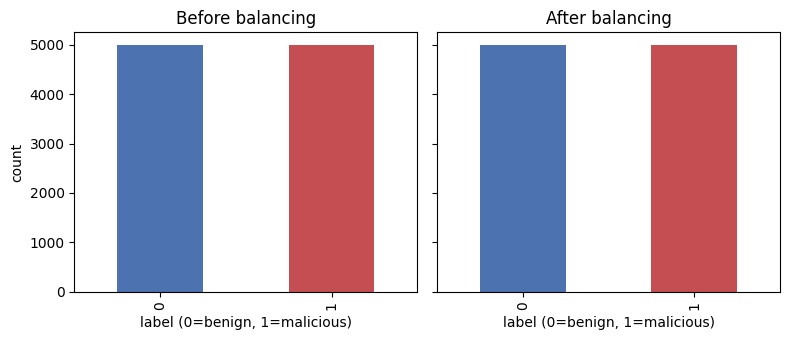

In [ ]:
counts_before = df["label"].value_counts().sort_index()
print("Class counts before balancing:")
print(counts_before)

n_per_class = int(counts_before.min())
print(f"\nDown-sampling both classes to {n_per_class:,} rows each.")

balanced_parts = [
    group.sample(n=n_per_class, random_state=RANDOM_SEED)
    for _, group in df.groupby("label")
]
df = (
    pd.concat(balanced_parts, axis=0)
    .sample(frac=1, random_state=RANDOM_SEED)  # shuffle
    .reset_index(drop=True)
)

audit.append(("5. After class balancing", len(df)))

counts_after = df["label"].value_counts().sort_index()
print("\nClass counts after balancing:")
print(counts_after)

fig, axes = plt.subplots(1, 2, figsize=(8, 3.5), sharey=True)
counts_before.plot(kind="bar", ax=axes[0], color=["#4C72B0", "#C44E52"])
axes[0].set_title("Before balancing")
axes[0].set_xlabel("label (0=benign, 1=malicious)")
axes[0].set_ylabel("count")
counts_after.plot(kind="bar", ax=axes[1], color=["#4C72B0", "#C44E52"])
axes[1].set_title("After balancing")
axes[1].set_xlabel("label (0=benign, 1=malicious)")
plt.tight_layout()
plt.show()

## Summary: Pipeline Audit Trail

The table below reports the row count after each of the five steps, so the
effect of every technique — and the pipeline as a whole — is traceable back
to the original `Final Dataset.csv` input.


In [ ]:
audit_df = pd.DataFrame(audit, columns=["Step", "Row count"])
audit_df["Rows removed"] = audit_df["Row count"].diff().fillna(0).astype(int).abs()
display(audit_df)

print(f"\nFinal preprocessed dataset: {len(df):,} rows, {df['label'].nunique()} classes, "
      f"perfectly balanced at {df['label'].value_counts().iloc[0]:,} rows per class.")

## Save the Preprocessed Dataset

The cleaned, standardized, tokenized, and balanced dataset is written to
`preprocessed_dataset.csv`. This is the input the next stage (lexical and
obfuscation-aware feature extraction) will consume. `url_raw` is kept as the
last column purely for traceability back to the original aggregated data.


In [ ]:
OUTPUT_PATH = "preprocessed_dataset.csv"

output_cols = ["url", "label", "subdomain", "domain", "path", "query", "url_raw"]
df[output_cols].to_csv(OUTPUT_PATH, index=False)

print(f"Wrote {len(df):,} rows to '{OUTPUT_PATH}'")
df[output_cols].head()

Wrote 10,000 rows to 'preprocessed_dataset.csv'


,url,label,subdomain,domain,path,query,url_raw
0,51-75-63-68.cprapid.com/eu/track.php?16d6oev751pp7e2ffowz,1,51-75-63-68,cprapid.com,/eu/track.php,16d6oev751pp7e2ffowz,https://51-75-63-68.cprapid.com/eu/track.php?16d6oev751pp7e2ffowz
1,builder.aws.com/?trk=8fe18e89-d22f-462a-8d9a-4fa301e62e02&sc_channel=ps,0,builder,aws.com,/,trk=8fe18e89-d22f-462a-8d9a-4fa301e62e02&sc_channel=ps,https://builder.aws.com/?trk=8fe18e89-d22f-462a-8d9a-4fa301e62e02&sc_channel=ps
2,www.mojohost.com,0,www,mojohost.com,,,https://www.mojohost.com
3,filesafe.space,0,,filesafe.space,,,https://filesafe.space
4,www.jappy.com/tl?url=_x_tr_sl%3dauto%26_x_tr_tl%3dor%26_x_tr_hl%3den-us%26_x...,0,www,jappy.com,/tl,url=_x_tr_sl%3dauto%26_x_tr_tl%3dor%26_x_tr_hl%3den-us%26_x_tr_pto%3dwapp%2f,https://www.jappy.com/tl?url=_x_tr_sl%3Dauto%26_x_tr_tl%3Dor%26_x_tr_hl%3Den...
